# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split ,GridSearchCV
from sklearn.preprocessing import StandardScaler ,OneHotEncoder , LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score , roc_auc_score , roc_curve
from sklearn.ensemble import GradientBoostingClassifier

import warnings
warnings.filterwarnings('ignore')

# Load Data

In [2]:
train_df = pd.read_csv(r'Rossmann/train.csv')

In [3]:
test_df = pd.read_csv(r'Rossmann/test.csv')

In [4]:
store_df = pd.read_csv(r'Rossmann/store.csv')

# Data Overview

In [5]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [6]:
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [7]:
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [8]:
train_df.shape

(1017209, 9)

In [9]:
test_df.shape

(41088, 8)

In [10]:
store_df.shape

(1115, 10)

# Missing Values - Train & Test

In [11]:
train_df.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [12]:
test_df.isnull().sum()

Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64

In [13]:
test_df[test_df["Open"].isnull()]["StateHoliday"]

479      0
1335     0
2191     0
3047     0
4759     0
5615     0
6471     0
7327     0
8183     0
9039     0
10751    0
Name: StateHoliday, dtype: str

In [14]:
test_df["Open"] = test_df["Open"].fillna(0)

In [15]:
test_df.isnull().sum()

Id               0
Store            0
DayOfWeek        0
Date             0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

# Missing Values - Store

In [16]:
store_df.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [17]:
train_df[train_df['Open'] == 0]["Sales"].sum()

np.int64(0)

In [18]:
store_df[store_df["CompetitionDistance"].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [19]:
store_df["CompetitionDistance"] = store_df["CompetitionDistance"].fillna(store_df["CompetitionDistance"].max()*3,axis=0)

In [20]:
store_df.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            0
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [21]:
store_df["CompetitionOpenSinceMonth"] = store_df["CompetitionOpenSinceMonth"].fillna(1)
store_df["CompetitionOpenSinceYear"] = store_df["CompetitionOpenSinceYear"].fillna(1)

In [22]:
store_df.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            0
CompetitionOpenSinceMonth      0
CompetitionOpenSinceYear       0
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [23]:
print(store_df[store_df["Promo2SinceWeek"].isnull()]["Promo2"].sum())
print(store_df[store_df["Promo2SinceYear"].isnull()]["Promo2"].sum())
print(store_df[store_df["PromoInterval"].isnull()]["Promo2"].sum())

0
0
0


In [24]:
store_df["Promo2SinceWeek"] = store_df["Promo2SinceWeek"].fillna(0)
store_df["Promo2SinceYear"] = store_df["Promo2SinceYear"].fillna(0)
store_df["PromoInterval"] = store_df["PromoInterval"].fillna("NoPromo")

In [25]:
store_df.isnull().sum()

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

# Merging Datasets

In [26]:
train_df_merged = pd.merge(store_df,train_df,on="Store")

In [27]:
train_df_merged.isnull().sum()

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
dtype: int64

In [28]:
test_df_merged = pd.merge(store_df,test_df,on="Store")

In [29]:
# Cleaning In test data

In [30]:
test_df_merged.isnull().sum()

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
Id                           0
DayOfWeek                    0
Date                         0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
dtype: int64

In [31]:
train_df_merged

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NoPromo,5,2015-07-31,5263,555,1,1,0,1
1,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NoPromo,4,2015-07-30,5020,546,1,1,0,1
2,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NoPromo,3,2015-07-29,4782,523,1,1,0,1
3,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NoPromo,2,2015-07-28,5011,560,1,1,0,1
4,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NoPromo,1,2015-07-27,6102,612,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1115,d,c,5350.0,1.0,1.0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",6,2013-01-05,4771,339,1,0,0,1
1017205,1115,d,c,5350.0,1.0,1.0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",5,2013-01-04,4540,326,1,0,0,1
1017206,1115,d,c,5350.0,1.0,1.0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",4,2013-01-03,4297,300,1,0,0,1
1017207,1115,d,c,5350.0,1.0,1.0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",3,2013-01-02,3697,305,1,0,0,1


# Exploratory Data Analysis

In [32]:
train_df_merged["StoreType"].value_counts()

StoreType
a    551627
d    312912
c    136840
b     15830
Name: count, dtype: int64

In [33]:
train_df_merged["Assortment"].value_counts()

Assortment
a    537445
c    471470
b      8294
Name: count, dtype: int64

## Sales Distribution

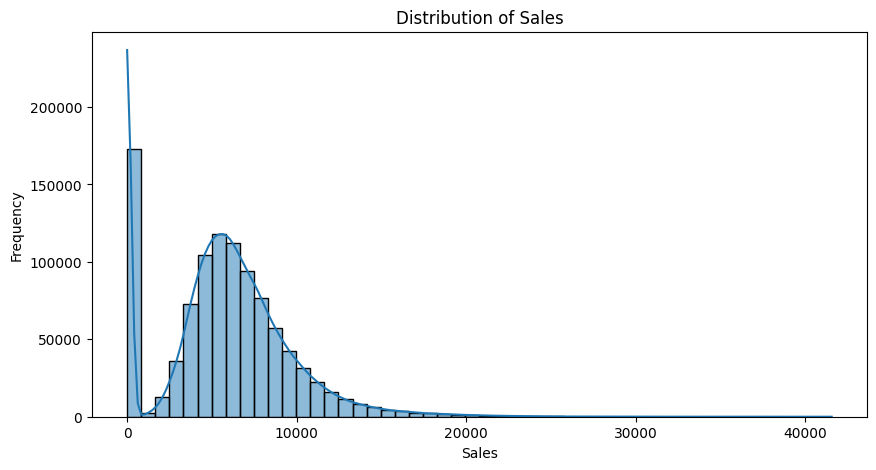

In [34]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df_merged["Sales"], bins=50, kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


## Sales by Store Type

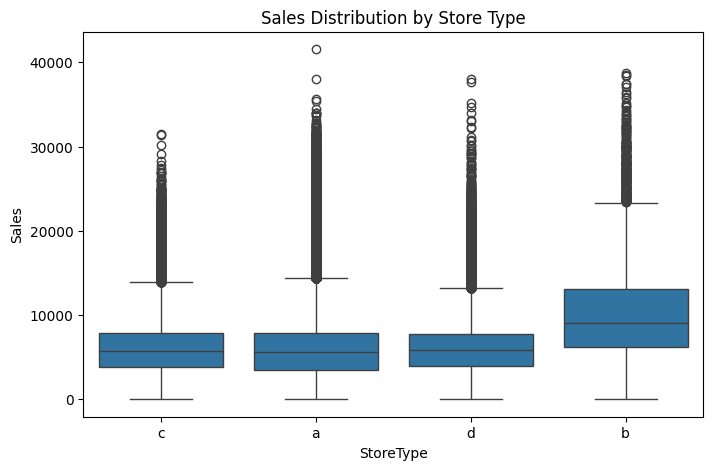

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="StoreType", y="Sales", data=train_df_merged)
plt.title("Sales Distribution by Store Type")
plt.show()


## Sales by Promo

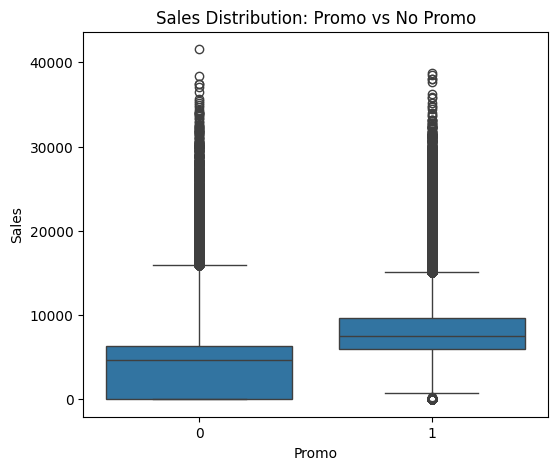

In [36]:
plt.figure(figsize=(6, 5))
sns.boxplot(x="Promo", y="Sales", data=train_df_merged)
plt.title("Sales Distribution: Promo vs No Promo")
plt.show()


## Correlation Heatmap

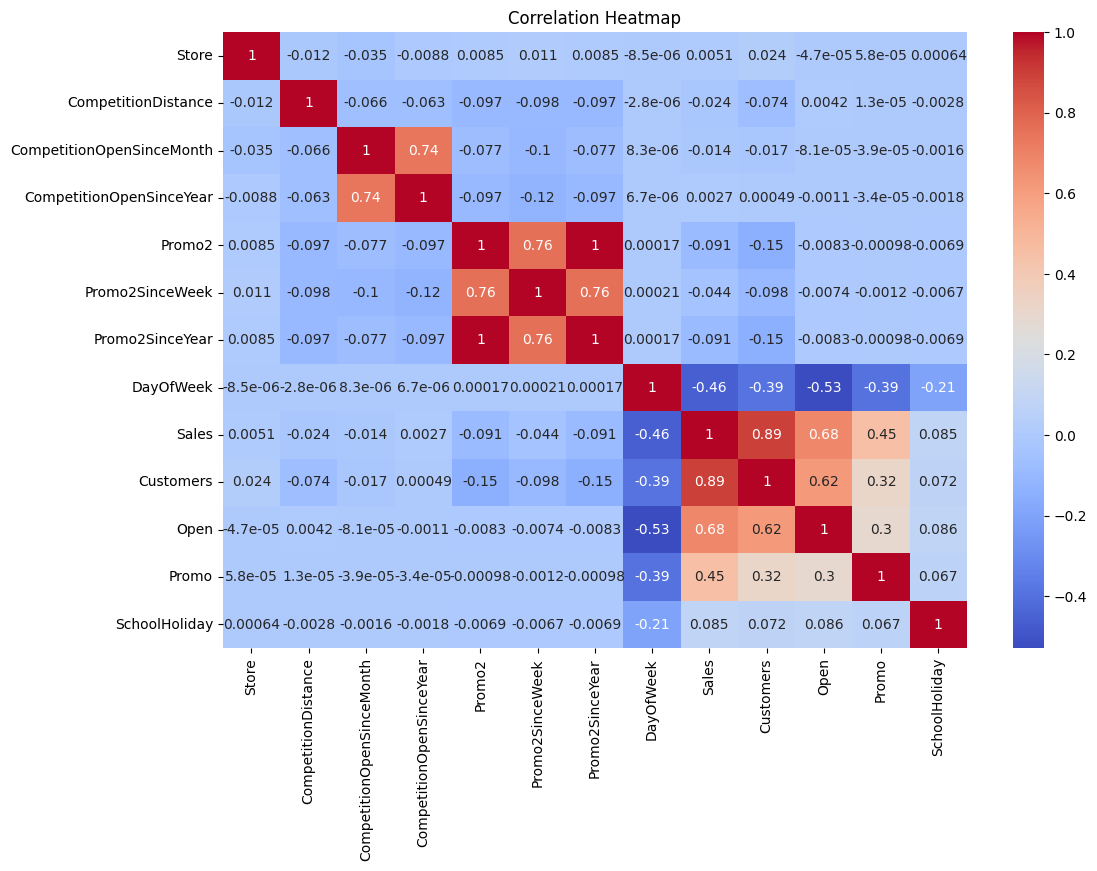

In [37]:
numeric_cols = train_df_merged.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_cols.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()


# Filter Closed Stores

In [38]:
train_df_copy = train_df_merged.copy()
test_df_copy = test_df_merged.copy()

In [39]:
train_df_copy[train_df_copy["Open"]!=0]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NoPromo,5,2015-07-31,5263,555,1,1,0,1
1,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NoPromo,4,2015-07-30,5020,546,1,1,0,1
2,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NoPromo,3,2015-07-29,4782,523,1,1,0,1
3,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NoPromo,2,2015-07-28,5011,560,1,1,0,1
4,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NoPromo,1,2015-07-27,6102,612,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017202,1115,d,c,5350.0,1.0,1.0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",1,2013-01-07,6905,471,1,1,0,1
1017204,1115,d,c,5350.0,1.0,1.0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",6,2013-01-05,4771,339,1,0,0,1
1017205,1115,d,c,5350.0,1.0,1.0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",5,2013-01-04,4540,326,1,0,0,1
1017206,1115,d,c,5350.0,1.0,1.0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",4,2013-01-03,4297,300,1,0,0,1


In [40]:
train_df_copy = train_df_copy[train_df_copy["Open"]!=0]
test_df_copy = test_df_copy[test_df_copy["Open"]!=0]

In [41]:
train_df_copy.shape

(844392, 18)

# Feature Engineering

In [42]:
train_df_copy["Date"] = pd.to_datetime(train_df_copy["Date"])
test_df_copy["Date"] = pd.to_datetime(test_df_copy["Date"])


In [43]:
train_df_copy["Year"] = train_df_copy["Date"].dt.year
train_df_copy["Month"] = train_df_copy["Date"].dt.month
train_df_copy["Day"] = train_df_copy["Date"].dt.day

test_df_copy["Year"] = test_df_copy["Date"].dt.year
test_df_copy["Month"] = test_df_copy["Date"].dt.month
test_df_copy["Day"] = test_df_copy["Date"].dt.day


In [44]:
train_df_copy["Diff_Months"] = (train_df_copy["Year"] - train_df_copy["CompetitionOpenSinceYear"])*12 + (train_df_copy["Month"] - train_df_copy["CompetitionOpenSinceMonth"])
test_df_copy["Diff_Months"] = (test_df_copy["Year"] - test_df_copy["CompetitionOpenSinceYear"])*12 + (test_df_copy["Month"] - test_df_copy["CompetitionOpenSinceMonth"])

In [45]:
train_df_copy[train_df_copy["Diff_Months"]<0]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,...,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,Diff_Months
3890,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,NoPromo,...,7692,659,1,1,0,0,2015,3,31,-1.0
3891,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,NoPromo,...,8847,770,1,1,0,0,2015,3,30,-1.0
3893,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,NoPromo,...,2038,219,1,0,0,0,2015,3,28,-1.0
3894,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,NoPromo,...,4181,499,1,0,0,0,2015,3,27,-1.0
3895,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,NoPromo,...,3711,460,1,0,0,0,2015,3,26,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013434,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",...,9444,735,1,1,0,0,2013,1,7,-17.0
1013436,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",...,3325,291,1,0,0,0,2013,1,5,-17.0
1013437,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",...,4640,453,1,0,0,1,2013,1,4,-17.0
1013438,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",...,4579,444,1,0,0,1,2013,1,3,-17.0


In [46]:
train_df_copy["Diff_Months"] = train_df_copy["Diff_Months"].clip(lower=0)
test_df_copy["Diff_Months"] = test_df_copy["Diff_Months"].clip(lower=0)

In [47]:
train_df_copy.info()

<class 'pandas.DataFrame'>
Index: 844392 entries, 0 to 1017207
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   StoreType                  844392 non-null  str           
 2   Assortment                 844392 non-null  str           
 3   CompetitionDistance        844392 non-null  float64       
 4   CompetitionOpenSinceMonth  844392 non-null  float64       
 5   CompetitionOpenSinceYear   844392 non-null  float64       
 6   Promo2                     844392 non-null  int64         
 7   Promo2SinceWeek            844392 non-null  float64       
 8   Promo2SinceYear            844392 non-null  float64       
 9   PromoInterval              844392 non-null  str           
 10  DayOfWeek                  844392 non-null  int64         
 11  Date                       844392 non-null  datetime64[us]
 12  Sal

# Encoding

In [48]:
cat_cols = train_df_copy.select_dtypes(include="object").columns.to_list()

In [49]:
for col in cat_cols:
    train_df_copy[col] = train_df_copy[col].astype(str)
    test_df_copy[col] = test_df_copy[col].astype(str)
    
    le = LabelEncoder()

    le.fit(pd.concat([train_df_copy[col], test_df_copy[col]], axis=0))
    
    train_df_copy[col] = le.transform(train_df_copy[col])
    test_df_copy[col] = le.transform(test_df_copy[col])

# Split Data

In [50]:
train_df_copy = train_df_copy.sort_values(by="Date")

split_date = '2015-05-19'

train_data = train_df_copy[train_df_copy["Date"]<split_date]
val_data = train_df_copy[train_df_copy["Date"]>=split_date]

In [51]:
print(train_data.shape)
print(val_data.shape)

(774534, 22)
(69858, 22)


In [52]:
drop_cols = ['Sales', 'Customers', 'Date', 'Open']

X_train = train_data.drop(columns=drop_cols)
y_train = train_data['Sales']

X_val = val_data.drop(columns=drop_cols)
y_val = val_data['Sales']

X_test = test_df_copy.drop(columns=['Customers', 'Date', 'Open'], errors='ignore')

In [53]:
print(X_train.shape,X_val.shape)

(774534, 18) (69858, 18)


In [54]:
X_train

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,DayOfWeek,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,Diff_Months
615999,676,1,1,1410.0,9.0,2008.0,0,0.0,0.0,3,2,0,1,1,2013,1,1,52.0
667669,733,1,1,860.0,10.0,1999.0,0,0.0,0.0,3,2,0,1,1,2013,1,1,159.0
512659,562,1,2,1210.0,1.0,1.0,0,0.0,0.0,3,2,0,1,1,2013,1,1,24144.0
450995,494,1,0,1260.0,6.0,2011.0,0,0.0,0.0,3,2,0,1,1,2013,1,1,19.0
238339,262,1,0,1180.0,5.0,2013.0,0,0.0,0.0,3,2,0,1,1,2013,1,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104908,116,0,0,680.0,4.0,2013.0,0,0.0,0.0,3,1,1,0,0,2015,5,18,25.0
448428,492,0,0,1740.0,3.0,2008.0,1,40.0,2012.0,1,1,1,0,0,2015,5,18,86.0
587034,645,0,0,90.0,1.0,1.0,1,45.0,2009.0,0,1,1,0,0,2015,5,18,24172.0
510850,561,3,0,14300.0,1.0,1.0,0,0.0,0.0,3,1,1,0,0,2015,5,18,24172.0


# AdaBoost

In [55]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [56]:
ada_model = AdaBoostRegressor(n_estimators=50,random_state=42)
ada_model.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [57]:
y_pred_ada = ada_model.predict(X_val)

rmse_ada = np.sqrt(mean_squared_error(y_val, y_pred_ada))
r2_ada = r2_score(y_val, y_pred_ada)

print(f"AdaBoost RMSE: {rmse_ada}")
print(f"AdaBoost R2 Score: {r2_ada}")

AdaBoost RMSE: 5403.02900317588
AdaBoost R2 Score: -2.127721495642928


# Gradient Boosting

In [58]:
from sklearn.ensemble import GradientBoostingRegressor


gb_model = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=7, 
    random_state=42
)


gb_model.fit(X_train, y_train)


y_pred_gb = gb_model.predict(X_val)

rmse_gb = np.sqrt(mean_squared_error(y_val, y_pred_gb))
r2_gb = r2_score(y_val, y_pred_gb)

print(f"Gradient Boosting RMSE: {rmse_gb:.2f}")
print(f"Gradient Boosting R2 Score: {r2_gb:.4f}")

Gradient Boosting RMSE: 1609.04
Gradient Boosting R2 Score: 0.7226


# Feature Importance

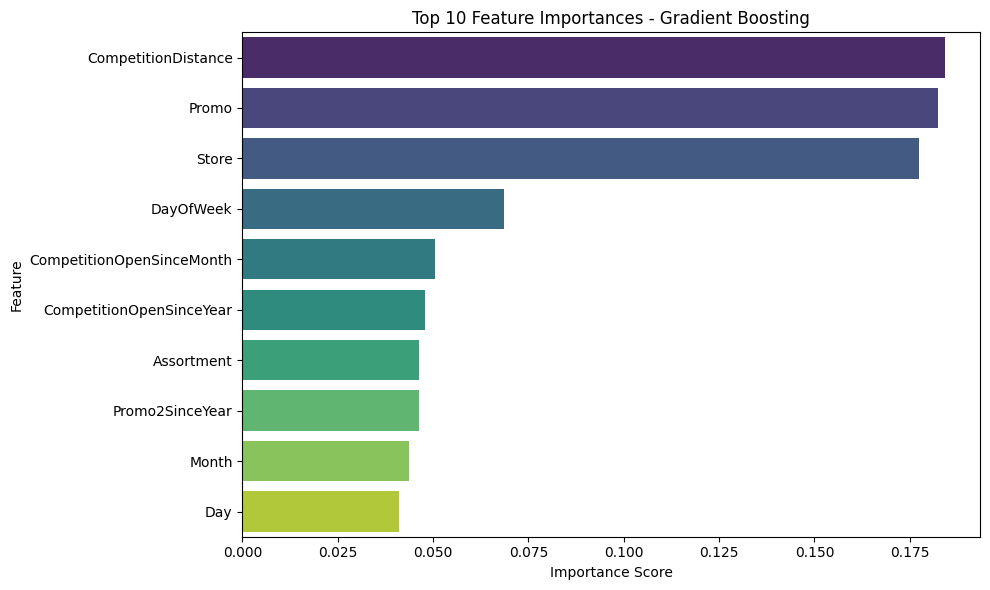

                      Feature  Importance
3         CompetitionDistance    0.184223
11                      Promo    0.182458
0                       Store    0.177325
10                  DayOfWeek    0.068588
4   CompetitionOpenSinceMonth    0.050490


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Feature Importances - Gradient Boosting')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


print(feature_importance.head(5))

# Generate Submission File

In [60]:
X_test_final = test_df_copy[X_train.columns].copy()


test_preds = gb_model.predict(X_test_final)

submission = pd.DataFrame({
    'Id': test_df_copy['Id'],
    'Sales': test_preds
})
submission.loc[test_df_copy['Open'] == 0, 'Sales'] = 0
submission = submission.sort_values('Id').reset_index(drop=True)


submission.to_csv('final_submission.csv', index=False)


# Saving Model

In [61]:
import joblib

joblib.dump(gb_model, 'gb_model.pkl')
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')
print("Model saved successfully!")

Model saved successfully!
